Build and evaluate classification models to predict whether a patient has heart disease. The target column is heart_disease (1 = disease present, 0 = absent).

Dataset columns: age, sex, chest_pain_type, resting_bp, cholesterol, fasting_bs, resting_ecg, max_hr, exercise_angina, oldpeak, st_slope, heart_disease

In [1]:
##Data Loading and Inspection
import pandas as pd
df = pd.read_csv("C:/pramod/New start of career/lectures/Assignment 4/part_a/q1_heart_disease.csv")


In [2]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt

In [3]:
## display its shape, data types, and missing value counts. Show the first five rows
df.shape


(800, 12)

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              800 non-null    int64  
 1   sex              800 non-null    int64  
 2   chest_pain_type  800 non-null    str    
 3   resting_bp       776 non-null    float64
 4   cholesterol      768 non-null    float64
 5   fasting_bs       800 non-null    int64  
 6   resting_ecg      800 non-null    str    
 7   max_hr           800 non-null    int64  
 8   exercise_angina  800 non-null    int64  
 9   oldpeak          800 non-null    float64
 10  st_slope         800 non-null    str    
 11  heart_disease    800 non-null    int64  
dtypes: float64(3), int64(6), str(3)
memory usage: 75.1 KB


In [5]:
df.isnull().sum()

age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

In [6]:
df.head()

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


2.Exploratory Data Analysis

In [7]:
df['sex'].value_counts()

sex
1    532
0    268
Name: count, dtype: int64

In [8]:
df['heart_disease'].value_counts()

heart_disease
1    407
0    393
Name: count, dtype: int64

Interpretion of each plot.  number of male are nearly double than femal but heart disease is equally distrubated

C:\Users\Pramod\AppData\Local\Temp\ipykernel_16032\723392577.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="heart_disease", y="cholesterol", palette="Set2")


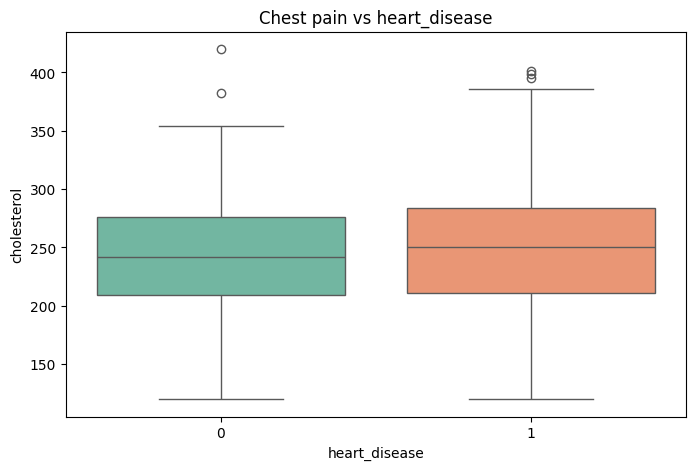

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="heart_disease", y="cholesterol", palette="Set2")

plt.title("Chest pain vs heart_disease")
plt.show()

Interpreation of box plot - Cholesterol level appx 250 may or may not have heart diesaase .data includes outliers in cholesterol level 

<Axes: xlabel='sex', ylabel='count'>

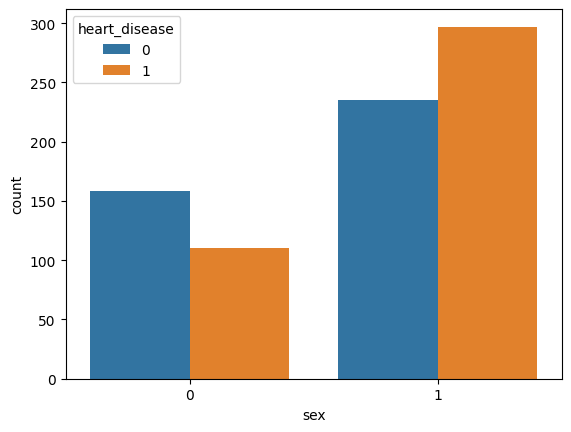

In [10]:
sns.countplot(x = df['sex'],hue = df['heart_disease'])

Interpreation of relation sex and heardiease - number of female and male with or without heart diease is 60:40

<Axes: >

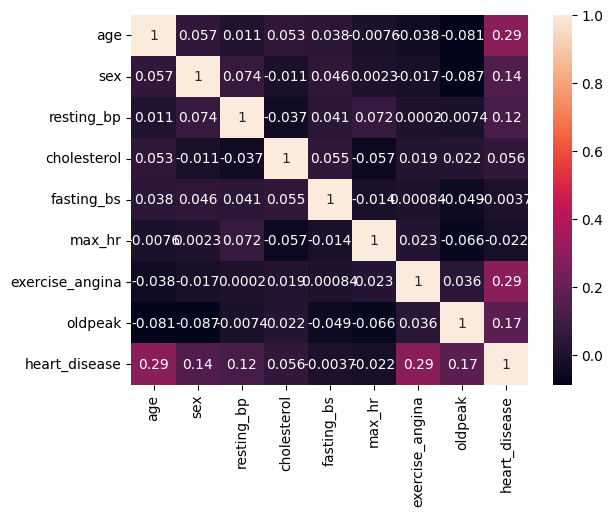

In [11]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

interpretion of heatmap... heart disease is connected to age 29% ,excercise angina 29%... cholesterol and fasting bs has less than 1% relation

3. Data Preprocessing

In [12]:
df.describe()

,age,sex,resting_bp,cholesterol,fasting_bs,max_hr,exercise_angina,oldpeak,heart_disease
count,800.000000,800.000000,776.000000,768.000000,800.00000,800.000000,800.000000,800.000000,800.000000
mean,52.191250,0.665000,130.668814,245.622396,0.23250,149.145000,0.295000,0.925500,0.508750
std,12.862211,0.472286,16.408805,52.185464,0.42269,22.396394,0.456328,0.897612,0.500236
min,30.000000,0.000000,90.000000,120.000000,0.00000,76.000000,0.000000,0.000000,0.000000
25%,41.000000,0.000000,120.000000,209.000000,0.00000,134.000000,0.000000,0.300000,0.000000
50%,53.000000,1.000000,130.000000,247.000000,0.00000,149.000000,0.000000,0.600000,1.000000
75%,63.000000,1.000000,142.000000,279.250000,0.00000,165.000000,1.000000,1.300000,1.000000
max,74.000000,1.000000,184.000000,420.000000,1.00000,202.000000,1.000000,5.700000,1.000000


Handle missing values with a documented strategy - resting bp and cholesterol has missing value 32 and 24 so it is filled with mean value .there are patient which has no fasting bs and in hitmap it shows less relation with heart disease.so i wll choose to drop it.

In [13]:
column_mean = df['cholesterol'].mean()
df['cholesterol'] = df['cholesterol'].fillna(column_mean)


In [14]:
column_mean1 = df['resting_bp'].mean()
df['resting_bp'] = df['resting_bp'].fillna(column_mean1)

In [15]:
df_encode = pd.get_dummies(df,drop_first=True)

df_encode

,age,sex,resting_bp,cholesterol,fasting_bs,max_hr,exercise_angina,oldpeak,heart_disease,chest_pain_type_atypical_angina,chest_pain_type_non_anginal,chest_pain_type_typical_angina,resting_ecg_normal,resting_ecg_st_t_wave_abnormality,st_slope_flat,st_slope_up
0,68,0,142.0,399.0,0,169,0,0.4,1,True,False,False,False,False,False,True
1,58,1,163.0,310.0,1,121,1,1.1,1,False,True,False,False,True,False,True
2,44,1,128.0,175.0,0,183,1,0.2,0,False,True,False,True,False,False,True
3,72,1,114.0,177.0,0,150,0,1.0,1,False,False,False,False,True,False,True
4,37,1,149.0,271.0,0,136,0,0.4,0,False,True,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,60,0,147.0,197.0,0,152,0,3.1,1,False,False,False,False,False,True,False
796,40,1,125.0,257.0,0,151,0,0.7,0,False,False,False,True,False,False,False
797,45,1,120.0,192.0,0,128,0,2.7,1,False,False,False,False,True,False,True
798,37,0,112.0,303.0,0,145,0,0.9,0,False,True,False,False,False,True,False


In [16]:
df_encode = df_encode.astype(int)
df_encode

,age,sex,resting_bp,cholesterol,fasting_bs,max_hr,exercise_angina,oldpeak,heart_disease,chest_pain_type_atypical_angina,chest_pain_type_non_anginal,chest_pain_type_typical_angina,resting_ecg_normal,resting_ecg_st_t_wave_abnormality,st_slope_flat,st_slope_up
0,68,0,142,399,0,169,0,0,1,1,0,0,0,0,0,1
1,58,1,163,310,1,121,1,1,1,0,1,0,0,1,0,1
2,44,1,128,175,0,183,1,0,0,0,1,0,1,0,0,1
3,72,1,114,177,0,150,0,1,1,0,0,0,0,1,0,1
4,37,1,149,271,0,136,0,0,0,0,1,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,60,0,147,197,0,152,0,3,1,0,0,0,0,0,1,0
796,40,1,125,257,0,151,0,0,0,0,0,0,1,0,0,0
797,45,1,120,192,0,128,0,2,1,0,0,0,0,1,0,1
798,37,0,112,303,0,145,0,0,0,0,1,0,0,0,1,0


In [17]:
from sklearn.preprocessing import StandardScaler
numerical_cols = ['age', 'resting_bp', 'cholesterol', 'max_hr', 'oldpeak']
scaler = StandardScaler()
df_encode[numerical_cols] = scaler.fit_transform(df_encode[numerical_cols])
df_encode.head()

,age,sex,resting_bp,cholesterol,fasting_bs,max_hr,exercise_angina,oldpeak,heart_disease,chest_pain_type_atypical_angina,chest_pain_type_non_anginal,chest_pain_type_typical_angina,resting_ecg_normal,resting_ecg_st_t_wave_abnormality,st_slope_flat,st_slope_up
0,1.229854,0,0.702830,3.002126,0,0.887081,0,-0.629113,1,1,0,0,0,0,0,1
1,0.451896,1,2.003076,1.260373,1,-1.257462,1,0.525222,1,0,1,0,0,1,0,1
2,-0.637245,1,-0.164001,-1.381611,0,1.512573,1,-0.629113,0,0,1,0,1,0,0,1
3,1.541037,1,-1.030832,-1.342471,0,0.038200,0,0.525222,1,0,0,0,0,1,0,1
4,-1.181815,1,1.136245,0.497133,0,-0.587292,0,-0.629113,0,0,1,0,1,0,1,0


In [18]:
from sklearn.model_selection import train_test_split


features = ['age','sex','chest_pain_type','resting_bp','cholesterol','resting_ecg','max_hr','exercise_angina','oldpeak','st_slope']
X = df[features]
y = df['heart_disease'] 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Train sample: {X_train.shape[0]}")
print(f"Testing sample: {X_test.shape[0]}")
print("Training set:")
print(y_train.value_counts(normalize=True))

Train sample: 640
Testing sample: 160
Training set:
heart_disease
1    0.509375
0    0.490625
Name: proportion, dtype: float64


4. Model Training

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix,f1_score


In [20]:
X_numeric = pd.get_dummies(X, drop_first=True)
X_numeric = X_numeric.fillna(0)
X_train, X_test, y_train, y_test = train_test_split(X_numeric, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(max_depth=10, random_state=42)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)


print("Model_result")
print(f"Accuracy:  {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred):.4f}")
print(f"Recall:    {recall_score(y_train, y_train_pred):.4f}")
print(f"F1:    {f1_score(y_train, y_train_pred):.4f}")






Model_result
Accuracy:  0.9797
Precision: 0.9813
Recall:    0.9783
F1:    0.9798


In [21]:
## randomforestclassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score


rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

print("Model_result")
print(f"Accuracy:  {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred):.4f}")
print(f"Recall:    {recall_score(y_train, y_train_pred):.4f}")
print(f"F1:    {f1_score(y_train, y_train_pred):.4f}")

Model_result
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1:    1.0000


In [22]:
##Gradient Boosting Classifier

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)


gb_model.fit(X_train, y_train)


y_train_pred = gb_model.predict(X_train)
y_test_pred = gb_model.predict(X_test)


print("Model_result")
print(f"Accuracy:  {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred):.4f}")
print(f"Recall:    {recall_score(y_train, y_train_pred):.4f}")
print(f"F1:    {f1_score(y_train, y_train_pred):.4f}")





Model_result
Accuracy:  0.9563
Precision: 0.9623
Recall:    0.9503
F1:    0.9563


5. Model Evaluation
Confusion matrix
Precision, Recall, and F1-score on the test set

In [23]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))
test_f1 = f1_score(y_test, y_test_pred, average='weighted')
print(f"Weighted F1-Score: {test_f1:.4f}")

Confusion Matrix:
[[60 15]
 [13 72]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.80      0.81        75
           1       0.83      0.85      0.84        85

    accuracy                           0.82       160
   macro avg       0.82      0.82      0.82       160
weighted avg       0.82      0.82      0.82       160

Weighted F1-Score: 0.8248
